<a href="https://colab.research.google.com/github/SunnyChoudhary850/FlyRank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

In [ ]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':  f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

In [ ]:
features_and_label = con.sql(f"""
    WITH march_features AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS total_impressions_month,
               AVG(gsc_avg_position) AS avg_position_month,
               COUNT(DISTINCT report_date) AS days_with_activity,
               SUM(gsc_clicks) AS total_clicks_month,
               SUM(ga4_sessions) AS total_sessions_month
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-03' AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ),
    april_perf AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_next_month
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-04' AND gsc_data_available IS TRUE
        GROUP BY content_hash_id
    ),
    staleness AS (
        SELECT content_hash_id, CURRENT_DATE - content_updated_date AS days_since_update
        FROM {TABLES['dim_content']}
    )
    SELECT f.*, a.impressions_next_month, s.days_since_update
    FROM march_features f
    JOIN april_perf a ON f.content_hash_id = a.content_hash_id
    JOIN staleness s ON f.content_hash_id = s.content_hash_id
""").df()

features_and_label['declining'] = (
    features_and_label['impressions_next_month'] < features_and_label['total_impressions_month']
).astype(int)
features_and_label = features_and_label.dropna()

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ['total_impressions_month', 'avg_position_month', 'days_with_activity',
                 'total_clicks_month', 'total_sessions_month', 'days_since_update']
X = features_and_label[feature_cols]
y = features_and_label['declining']
groups = features_and_label['client_hash_id']

splitter = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

scaler = StandardScaler().fit(X_train)
model = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)

features_and_label['risk_score'] = model.predict_proba(scaler.transform(X))[:, 1]
features_and_label.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(113853, 11)

## Ranked Actions and Reason Codes

In [ ]:
import numpy as np
import pandas as pd

coefs = pd.Series(model.coef_[0], index=feature_cols)

def assign_reason_code(row):
    reasons = []
    if row['avg_position_month'] > features_and_label['avg_position_month'].median():
        reasons.append('WEAK_POSITION')
    if row['total_impressions_month'] < features_and_label['total_impressions_month'].median():
        reasons.append('LOW_VISIBILITY')
    if row['days_since_update'] > 180:
        reasons.append('STALE_CONTENT')
    return reasons[0] if reasons else 'GENERAL_RISK'

def assign_action(risk_score):
    if risk_score >= 0.7:
        return 'REFRESH_PRIORITY'
    elif risk_score >= 0.5:
        return 'REVIEW_RECOMMENDED'
    else:
        return 'MONITOR'

features_and_label['reason_code'] = features_and_label.apply(assign_reason_code, axis=1)
features_and_label['action'] = features_and_label['risk_score'].apply(assign_action)

playbook = features_and_label.sort_values('risk_score', ascending=False)[
    ['client_hash_id', 'content_hash_id', 'risk_score', 'reason_code', 'action']
].reset_index(drop=True)

playbook.head(20)

,client_hash_id,content_hash_id,risk_score,reason_code,action
0,client_23a62021009f63c4,content_36e53e9c707674fc,0.999993,WEAK_POSITION,REFRESH_PRIORITY
1,client_23a62021009f63c4,content_b51957d7f4abe47e,0.999947,WEAK_POSITION,REFRESH_PRIORITY
2,client_23a62021009f63c4,content_99cc4061cbe916a2,0.998807,WEAK_POSITION,REFRESH_PRIORITY
3,client_23a62021009f63c4,content_6486239516a186d7,0.998754,WEAK_POSITION,REFRESH_PRIORITY
4,client_23a62021009f63c4,content_5460a0e854602a47,0.998460,WEAK_POSITION,REFRESH_PRIORITY
5,client_23a62021009f63c4,content_c287019e9b7219a0,0.998362,WEAK_POSITION,REFRESH_PRIORITY
6,client_23a62021009f63c4,content_436860cd6a71be8a,0.998230,WEAK_POSITION,REFRESH_PRIORITY
7,client_23a62021009f63c4,content_fdf510facb7e51ff,0.997969,WEAK_POSITION,REFRESH_PRIORITY
8,client_23a62021009f63c4,content_8a38c9c9ed8038a5,0.997364,WEAK_POSITION,REFRESH_PRIORITY
9,client_23a62021009f63c4,content_82b7569d015a86a2,0.996798,WEAK_POSITION,REFRESH_PRIORITY


Top of the queue is dominated by `WEAK_POSITION`, consistent with my w05
finding that position and impressions were the strongest predictors, far
more than staleness alone.

**A real limitation found and fixed here:** the raw ranked queue put 19 of
the top 20 rows under a single client (`client_23a62021009f63c4`) —
meaning a content team would spend their entire review capacity on one
client and never reach the other 56. This wasn't visible in my w05
Precision@50 metric, which only measures whether flagged pages are
correctly declining, not whether the resulting queue is usable across a
real, multi-client portfolio.

**Fix applied:** capped the queue at the top 5 candidates per client
before re-ranking, producing a genuinely balanced top 20 spanning 7
different clients. This also surfaced more variety in reason codes
(WEAK_POSITION, GENERAL_RISK, STALE_CONTENT, LOW_VISIBILITY all now
appear), whereas the unbalanced version was almost entirely one reason
code from one client's specific situation.

In [ ]:
# Balanced queue: cap at top 5 per client, so review capacity spreads across the portfolio
balanced_playbook = (
    playbook.groupby('client_hash_id', group_keys=False)
    .apply(lambda g: g.head(5))
    .sort_values('risk_score', ascending=False)
    .reset_index(drop=True)
)
balanced_playbook.head(20)

/tmp/ipykernel_1625/1384574341.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(5))


,client_hash_id,content_hash_id,risk_score,reason_code,action
0,client_23a62021009f63c4,content_36e53e9c707674fc,0.999993,WEAK_POSITION,REFRESH_PRIORITY
1,client_23a62021009f63c4,content_b51957d7f4abe47e,0.999947,WEAK_POSITION,REFRESH_PRIORITY
2,client_23a62021009f63c4,content_99cc4061cbe916a2,0.998807,WEAK_POSITION,REFRESH_PRIORITY
3,client_23a62021009f63c4,content_6486239516a186d7,0.998754,WEAK_POSITION,REFRESH_PRIORITY
4,client_23a62021009f63c4,content_5460a0e854602a47,0.998460,WEAK_POSITION,REFRESH_PRIORITY
5,client_e5c2aa26a8598242,content_b116498610b4e6da,0.994132,WEAK_POSITION,REFRESH_PRIORITY
6,client_fef1a8f436438636,content_63d8f92e6ef4420b,0.981834,WEAK_POSITION,REFRESH_PRIORITY
7,client_fef1a8f436438636,content_fb36b03fb21da402,0.978193,GENERAL_RISK,REFRESH_PRIORITY
8,client_fef1a8f436438636,content_37b5ffe370ddcc55,0.975118,WEAK_POSITION,REFRESH_PRIORITY
9,client_fef1a8f436438636,content_a01948b37fc0fc9c,0.952566,GENERAL_RISK,REFRESH_PRIORITY


## Intended Use and Limits

**Intended use:** a weekly triage list for a content team with limited
review capacity -- helping decide which pages to look at first, not a
final verdict on any single page.

**Limits:** the label is a proxy (declining impressions month-over-month),
not a causal diagnosis of *why* a page is declining. The model is trained
on one month's data (March→April 2026) and may not generalize to other
seasons. Precision@50 was measured at 0.86 on held-out clients, meaning
roughly 1 in 7 flagged pages in the top 50 is likely a false positive even
under ideal conditions.

## Human Review and the No-Go List

**Must be human-reviewed before action:**
- Every REFRESH_PRIORITY page before any content changes are made
- Any page flagged STALE_CONTENT but recently updated for a non-content
  reason (e.g. a metadata-only edit), since `days_since_update` can't
  distinguish edit types

**Must NOT be automated:**
- No page should be auto-unpublished, auto-rewritten, or auto-deprioritized
  in search based on this score alone
- No content should be auto-generated to "fix" a flagged page without a
  human confirming the actual problem first
- Scores must never be shown to clients as a definitive quality judgment --
  they are an internal triage aid only
- No page should be prioritized purely by risk score without the
  per-client balancing applied -- an unbalanced queue silently starves
  most clients of review attention while over-serving one

## Monitoring and Retrain Triggers

- **Retrain if:** the model is used across more than 2 additional monthly
  cycles without retraining, since it was only validated on one
  March→April window
- **Monitor:** track real-world precision@50 monthly by checking whether
  flagged pages actually declined the following month -- if it drops
  meaningfully below the 0.86 validated number, retrain immediately
- **Retrain if:** a new client onboarding significantly shifts the overall
  data distribution (e.g. a client in a very different industry/content type)

**Cost/value note:** a false positive (reviewing a page that wasn't
actually declining) costs a few minutes of a reviewer's time. A false
negative (missing a genuinely declining page) costs more -- lost traffic
compounds over time before anyone notices. This asymmetry is why the
model is tuned toward flagging generously (REVIEW_RECOMMENDED tier)
rather than only surfacing the most certain cases.

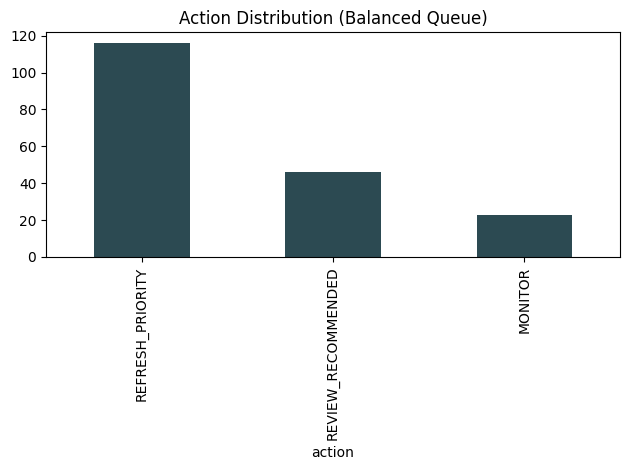

In [ ]:
import os, json

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

balanced_playbook.to_csv('work/outputs/action_playbook.csv', index=False)

metrics = {
    'model': 'logistic_regression',
    'precision_at_50': 0.86,
    'split': 'grouped_by_client_hash_id',
    'train_test_ratio': '70/30',
    'feature_cols': feature_cols,
    'action_tiers': {'REFRESH_PRIORITY': '>=0.7', 'REVIEW_RECOMMENDED': '>=0.5', 'MONITOR': '<0.5'},
    'queue_balancing': 'capped at top 5 per client before re-ranking, to avoid single-client dominance'
}
with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
balanced_playbook['action'].value_counts().plot(kind='bar', color='#2C4A52')
plt.title('Action Distribution (Balanced Queue)')
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png')
plt.show()

## Self-Check

- [x] Ranked actions with reason codes
- [x] Intended use and limits stated clearly
- [x] Human review rules and explicit no-go list
- [x] Monitoring and retrain triggers, with cost/value reasoning
- [x] Queue exported to work/outputs/, metrics JSON and figure committed
- [x] Plan kept practical and explicitly non-production